<a href="https://colab.research.google.com/github/sethkipsangmutuba/Database-Management-System/blob/main/f4.%20Data_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Modeling Using the Entity-Relationship (ER) Model

## 1. Conceptual Modeling in Database Design

- **Database Application**: A database along with programs that manage database operations (e.g., updates for customer deposits/withdrawals in a bank system).

- **Software Engineering vs Database Design**:
  - **Database Design**: Focuses on structures and constraints.
  - **Application Programming**: Falls under **Software Engineering**, but both are interrelated.

## 2. Entity-Relationship (ER) Model

- **Purpose**: The ER model is a high-level conceptual data model widely used in database design to structure data and define relationships.

- **ER Diagrams**: A visual representation showing entities, their attributes, and relationships. ER model focuses on **data structuring**, not the operations on data.

## 3. Object Modeling (UML)

- **UML (Unified Modeling Language)**: Extends ER models by including **class diagrams** that also specify **operations (functions)** on entities, beyond just their structure.

- **Difference**:
  - ER diagrams focus on **structure**.
  - UML class diagrams include both **structure** and **behavior**.

## 4. Key Topics in ER Model

- **Entities and Attributes**:
  - **Entities**: Represent real-world objects (e.g., **Customer**).
  - **Attributes**: Describe properties of entities (e.g., **Name**, **Account Number**).

- **Binary Relationships**: Define how entities interact (e.g., **Customer** owns an **Account**).

- **Weak Entities**: Entities that depend on others for identification (e.g., **Order Item** in an **Order**).

## 5. Refining the Database Schema

- **Relationships and Constraints**:
  - Adding relationships between entities and defining structural constraints (e.g., one-to-many, many-to-many).

## 6. Advanced Concepts

- **Enhanced-ER (EER) Model**: Extends the ER model with advanced concepts like **specialization**, **generalization**, **inheritance**, and **union types (categories)**.

## 7. Overview

### Sections:
- **Section 7.1**: Role of conceptual data models.
- **Section 7.2**: Example database application.
- **Section 7.3**: Entities and attributes.
- **Section 7.4**: Binary relationships.
- **Section 7.5**: Weak entities.
- **Section 7.6**: Refining schema with relationships.
- **Section 7.7**: Notation, naming, and common pitfalls.
- **Sections 7.8 & 7.9**: UML class diagrams and complex relationships (optional for introductory courses).


# Using High-Level Conceptual Data Models for Database Design

## 7.1 Overview of the Database Design Process

### Requirements Collection and Analysis:
- **Purpose**: Interview database users to gather and document their data and functional requirements.
- **Result**: A detailed and complete set of user requirements.
- **In Parallel**: Functional requirements (user-defined operations like data retrievals and updates) are specified.

## 7.2 Conceptual Design

- After gathering and analyzing requirements, the next step is to create a **conceptual schema** using a high-level conceptual data model (e.g., ER model).
  
### Conceptual Schema:
- A concise description of the users' data requirements, including **entity types**, **relationships**, and **constraints**.
  
### Advantage:
- No implementation details, making it easier to understand and communicate with non-technical users.

## 7.3 Mapping Functional Requirements

- During or after conceptual schema design, use the basic data model operations to specify user queries and operations.
- This ensures the conceptual schema meets all the functional requirements.
- Modifications may be made to the schema if some requirements cannot be represented in the initial design.

## 7.4 Logical Design (Data Model Mapping)

- The **conceptual schema** is transformed into a **logical schema** tailored to the DBMS's implementation data model (e.g., relational, object-relational).
  
### Logical Design:
- This is called **logical design** or **data model mapping**.
- Result: A database schema specific to the chosen **DBMS data model**.
- Often automated or semi-automated through design tools.

## 7.5 Physical Design

- **Physical Design** involves specifying the internal storage structures, file organizations, and access paths for the database.
- Also includes designing **indexes** and setting physical design parameters for database files.

### Application Programs:
- These are designed and implemented as transactions based on high-level transaction specifications.

## 7.6 Sample Database Application (COMPANY)

### COMPANY Database:
- Keeps track of employees, departments, and projects.

### Miniworld Description:
- **Departments**:
  - Unique name and number.
  - A manager (employee) with the start date of their management role.
  - Multiple locations.

- **Projects**:
  - Controlled by departments, each project has a unique name, number, and location.

- **Employees**:
  - Data stored: **name**, **SSN**, **address**, **salary**, **gender**, **birth date**.
  - Employees are assigned to one department but may work on several projects, which may not be controlled by the same department.
  - **Supervisor**: Each employee has a direct supervisor (another employee).
  - **Dependents**: Tracked for insurance purposes with their **first name**, **sex**, **birth date**, and **relationship to the employee**.

### ER Diagram:
- The conceptual schema for this database will be represented as an **ER diagram**, illustrating entities like departments, projects, employees, and their relationships.

## 7.7 Conclusion

- The **conceptual design phase** (using high-level models like ER) enables database designers to focus on **data properties** without worrying about technical implementation, ensuring a thorough and **user-centered design**.


##Install Required Libraries

In [26]:
!pip install networkx matplotlib sqlite3


ERROR: Could not find a version that satisfies the requirement sqlite3 (from versions: none)
ERROR: No matching distribution found for sqlite3


##Create ER Diagram for COMPANY Database

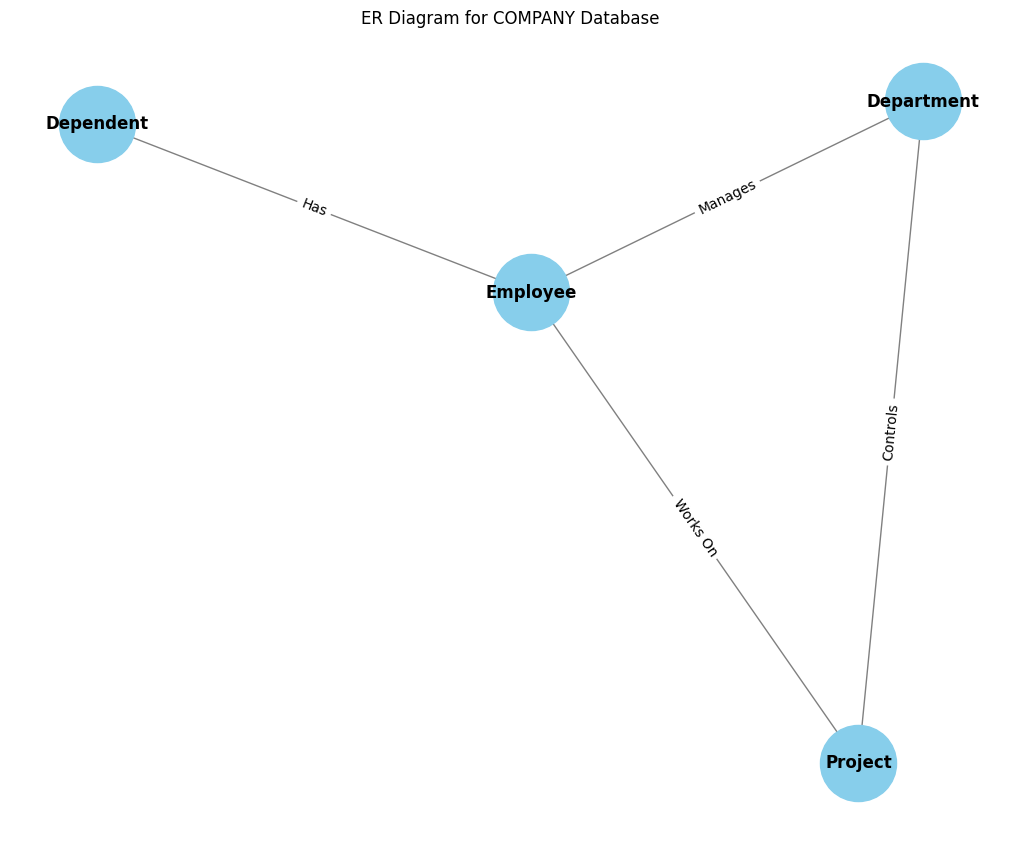

In [27]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph to represent entities and their relationships
G = nx.Graph()

# Add nodes representing entities (departments, employees, projects, dependents)
G.add_node("Department")
G.add_node("Employee")
G.add_node("Project")
G.add_node("Dependent")

# Add relationships (edges) between the entities
G.add_edge("Department", "Employee", relationship="Manages")
G.add_edge("Employee", "Project", relationship="Works On")
G.add_edge("Department", "Project", relationship="Controls")
G.add_edge("Employee", "Dependent", relationship="Has")

# Define layout and visualize the ER diagram
pos = nx.spring_layout(G)
plt.figure(figsize=(10, 8))

# Draw the graph with labels for the nodes and edges
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='skyblue', font_size=12, font_weight='bold', edge_color='gray')

# Label the relationships (edges)
edge_labels = nx.get_edge_attributes(G, "relationship")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Display the graph
plt.title("ER Diagram for COMPANY Database")
plt.show()


###Create the Database Schema in SQLite

In [28]:
import sqlite3

# Re-create the database schema with the missing department_id in Employee table
def create_schema():
    with sqlite3.connect('company.db') as conn:
        cursor = conn.cursor()

        # Drop existing tables if they exist (to avoid conflicts)
        cursor.execute('DROP TABLE IF EXISTS Department')
        cursor.execute('DROP TABLE IF EXISTS Employee')
        cursor.execute('DROP TABLE IF EXISTS Project')
        cursor.execute('DROP TABLE IF EXISTS Dependent')

        # Create the Department table
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS Department (
            department_id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT NOT NULL,
            manager_id INTEGER,  -- Foreign key to Employee
            FOREIGN KEY (manager_id) REFERENCES Employee(employee_id)
        );
        ''')

        # Create the Employee table with department_id
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS Employee (
            employee_id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT NOT NULL,
            ssn TEXT UNIQUE,
            address TEXT,
            salary REAL,
            gender TEXT,
            birth_date TEXT,
            department_id INTEGER,  -- Foreign key to Department
            FOREIGN KEY (department_id) REFERENCES Department(department_id)
        );
        ''')

        # Create the Project table
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS Project (
            project_id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT NOT NULL,
            department_id INTEGER,  -- Foreign key to Department
            location TEXT,
            FOREIGN KEY (department_id) REFERENCES Department(department_id)
        );
        ''')

        # Create the Dependent table
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS Dependent (
            dependent_id INTEGER PRIMARY KEY AUTOINCREMENT,
            employee_id INTEGER,  -- Foreign key to Employee
            first_name TEXT,
            sex TEXT,
            birth_date TEXT,
            relationship TEXT,
            FOREIGN KEY (employee_id) REFERENCES Employee(employee_id)
        );
        ''')

        # Commit and close the connection
        conn.commit()

    print("Database schema created successfully.")

# Run the function to create the schema
create_schema()


Database schema created successfully.


###Insert Sample Data into the Database

In [29]:
def insert_data():
    with sqlite3.connect('company.db') as conn:
        cursor = conn.cursor()

        # Insert sample departments first
        cursor.execute("INSERT INTO Department (name, manager_id) VALUES ('HR', NULL)")
        cursor.execute("INSERT INTO Department (name, manager_id) VALUES ('Engineering', NULL)")

        # Get department IDs
        cursor.execute("SELECT department_id FROM Department WHERE name='HR'")
        hr_id = cursor.fetchone()[0]
        cursor.execute("SELECT department_id FROM Department WHERE name='Engineering'")
        eng_id = cursor.fetchone()[0]

        # Insert sample employees, linking them to departments
        cursor.execute("INSERT INTO Employee (name, ssn, address, salary, gender, birth_date, department_id) VALUES ('Alice', '123-45-6789', '123 Elm St', 60000, 'F', '1985-04-12', ?)", (hr_id,))
        cursor.execute("INSERT INTO Employee (name, ssn, address, salary, gender, birth_date, department_id) VALUES ('Bob', '987-65-4321', '456 Oak St', 75000, 'M', '1983-08-24', ?)", (eng_id,))

        # Get employee IDs for Alice and Bob (to use as manager_id)
        cursor.execute("SELECT employee_id FROM Employee WHERE name='Alice'")
        alice_id = cursor.fetchone()[0]
        cursor.execute("SELECT employee_id FROM Employee WHERE name='Bob'")
        bob_id = cursor.fetchone()[0]

        # Update departments with manager_id
        cursor.execute("UPDATE Department SET manager_id = ? WHERE name = 'HR'", (alice_id,))
        cursor.execute("UPDATE Department SET manager_id = ? WHERE name = 'Engineering'", (bob_id,))

        # Insert projects for each department
        cursor.execute("INSERT INTO Project (name, department_id, location) VALUES ('Employee Database', ?, 'New York')", (hr_id,))
        cursor.execute("INSERT INTO Project (name, department_id, location) VALUES ('Web Development', ?, 'San Francisco')", (eng_id,))

        # Insert dependents for Alice and Bob
        cursor.execute("INSERT INTO Dependent (employee_id, first_name, sex, birth_date, relationship) VALUES (?, 'Charlie', 'M', '2012-03-14', 'Son')", (alice_id,))
        cursor.execute("INSERT INTO Dependent (employee_id, first_name, sex, birth_date, relationship) VALUES (?, 'David', 'M', '2015-06-20', 'Son')", (bob_id,))

    print("Sample data inserted successfully.")

# Run the insert function
insert_data()


Sample data inserted successfully.


###Query Data from the Database

In [30]:
def query_data():
    with sqlite3.connect('company.db') as conn:
        cursor = conn.cursor()

        # Example query: Get all employees in the 'Engineering' department
        cursor.execute('''
        SELECT e.name, e.salary
        FROM Employee e
        JOIN Department d ON e.department_id = d.department_id
        WHERE d.name = 'Engineering';
        ''')

        employees = cursor.fetchall()
        for employee in employees:
            print(f"Employee: {employee[0]}, Salary: {employee[1]}")

# Run the query function
query_data()


Employee: Bob, Salary: 75000.0


###Check inserted data

In [31]:
def check_data():
    with sqlite3.connect('company.db') as conn:
        cursor = conn.cursor()

        # Check all departments
        cursor.execute("SELECT * FROM Department")
        departments = cursor.fetchall()
        print("Departments:")
        for dept in departments:
            print(dept)

        # Check all employees
        cursor.execute("SELECT * FROM Employee")
        employees = cursor.fetchall()
        print("\nEmployees:")
        for emp in employees:
            print(emp)

        # Check all projects
        cursor.execute("SELECT * FROM Project")
        projects = cursor.fetchall()
        print("\nProjects:")
        for proj in projects:
            print(proj)

        # Check all dependents
        cursor.execute("SELECT * FROM Dependent")
        dependents = cursor.fetchall()
        print("\nDependents:")
        for dep in dependents:
            print(dep)

# Run this function to check if data is inserted correctly
check_data()


Departments:
(1, 'HR', 1)
(2, 'Engineering', 2)

Employees:
(1, 'Alice', '123-45-6789', '123 Elm St', 60000.0, 'F', '1985-04-12', 1)
(2, 'Bob', '987-65-4321', '456 Oak St', 75000.0, 'M', '1983-08-24', 2)

Projects:
(1, 'Employee Database', 1, 'New York')
(2, 'Web Development', 2, 'San Francisco')

Dependents:
(1, 1, 'Charlie', 'M', '2012-03-14', 'Son')
(2, 2, 'David', 'M', '2015-06-20', 'Son')


# 7.3 Entity Types, Entity Sets, Attributes, and Keys

## 7.3.1 Entities and Attributes

### Entity:
- A **real-world object** with independent existence (e.g., **person**, **company**).
- Can be **Physical** (e.g., **Car**, **House**) or **Conceptual** (e.g., **Job**, **University**).

### Attributes:
- **Properties** describing entities (e.g., **Name**, **Age**, **Address**).

#### Types of Attributes:

- **Simple (Atomic)** vs. **Composite**:
  - **Simple**: Indivisible (e.g., **Age**).
  - **Composite**: Divisible into subparts (e.g., **Address** → Street, City, Zip).

- **Single-Valued** vs. **Multivalued**:
  - **Single**: One value per entity (e.g., **Salary**).
  - **Multivalued**: Multiple values (e.g., **Colors** for a car).

- **Stored** vs. **Derived**:
  - **Stored**: Directly stored (e.g., **Birth_date**).
  - **Derived**: Computed from stored (e.g., **Age** from **Birth_date**).

- **NULL Values**:
  - Used when data is **unknown** or **not applicable**.
  - Example: **NULL** for **Apartment_number** if a person lives in a house.

- **Complex Attributes**:
  - Nesting of multivalued and composite attributes.
  - Example: `{Address_phone({Phone(Area_code, Number)}, Address(...))}`.

## 7.3.2 Entity Types, Entity Sets, Keys, and Value Sets

### Entity Type:
- Describes a **group of similar entities** (e.g., **EMPLOYEE**).

### Entity Set:
- **Collection** of all entities of a given type at a point in time.

### ER Diagram Notation:
- **Rectangle** = Entity
- **Oval** = Attribute
- **Double oval** = Multivalued attribute
- **Underlined** = Key attribute

### Key Attributes:
- **Uniquely identify an entity**.
- May be **simple** or **composite** (minimal set of attributes).
- Example: **Ssn** for **PERSON**, **Registration(State, Number)** for **CAR**.

### Value Sets (Domains):
- Each attribute has an associated **domain** of possible values.
- Not shown in ER diagram, but **critical** for schema design.
- Mathematically, attribute A maps entity e to values in power set P(V).

## 7.3.3 Initial Conceptual Design of COMPANY Database

### Defined 4 entity types:

#### **DEPARTMENT**:
- **Attributes**:
  - **Name** (Key), **Number** (Key), **Locations** (multivalued), **Manager**, **Manager_start_date**.

#### **PROJECT**:
- **Attributes**:
  - **Name** (Key), **Number** (Key), **Location**, **Controlling_department**.

#### **EMPLOYEE**:
- **Attributes**:
  - **Name** (composite), **Ssn** (Key), **Sex**, **Address**, **Salary**, **Birth_date**, **Department**, **Supervisor**.
  - Includes a composite multivalued attribute **Works_on**(**Project**, **Hours**).

#### **DEPENDENT**:
- **Attributes**:
  - **Employee** (Foreign Key), **Dependent_name**, **Sex**, **Birth_date**, **Relationship**.


####Database Schema

In [32]:
import sqlite3

def create_schema():
    with sqlite3.connect('company.db') as conn:
        cursor = conn.cursor()

        # Drop existing tables to avoid conflicts
        cursor.execute('DROP TABLE IF EXISTS Department')
        cursor.execute('DROP TABLE IF EXISTS Project')
        cursor.execute('DROP TABLE IF EXISTS Employee')
        cursor.execute('DROP TABLE IF EXISTS Dependent')

        # Create Department Table
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS Department (
            department_id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT NOT NULL,
            number TEXT NOT NULL,
            manager_id INTEGER,
            manager_start_date TEXT,
            locations TEXT,
            FOREIGN KEY (manager_id) REFERENCES Employee(employee_id)
        );
        ''')

        # Create Project Table
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS Project (
            project_id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT NOT NULL,
            number TEXT NOT NULL,
            location TEXT,
            controlling_department_id INTEGER,  -- Foreign key to Department
            FOREIGN KEY (controlling_department_id) REFERENCES Department(department_id)
        );
        ''')

        # Create Employee Table
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS Employee (
            employee_id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT NOT NULL,
            ssn TEXT UNIQUE,
            sex TEXT,
            address TEXT,
            salary REAL,
            birth_date TEXT,
            department_id INTEGER,  -- Foreign key to Department
            supervisor_id INTEGER,  -- Foreign key to Supervisor (Employee)
            FOREIGN KEY (department_id) REFERENCES Department(department_id),
            FOREIGN KEY (supervisor_id) REFERENCES Employee(employee_id)
        );
        ''')

        # Create Dependent Table
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS Dependent (
            dependent_id INTEGER PRIMARY KEY AUTOINCREMENT,
            employee_id INTEGER,  -- Foreign key to Employee
            dependent_name TEXT,
            sex TEXT,
            birth_date TEXT,
            relationship TEXT,
            FOREIGN KEY (employee_id) REFERENCES Employee(employee_id)
        );
        ''')

    print("Database schema created successfully.")

# Run the function to create the schema
create_schema()


Database schema created successfully.


### Inserting Data Based on Entity Types

In [33]:
def insert_data():
    with sqlite3.connect('company.db') as conn:
        cursor = conn.cursor()

        # Insert sample departments
        cursor.execute("INSERT INTO Department (name, number, locations) VALUES ('HR', 'D001', 'New York')")
        cursor.execute("INSERT INTO Department (name, number, locations) VALUES ('Engineering', 'D002', 'San Francisco')")

        # Get department IDs
        cursor.execute("SELECT department_id FROM Department WHERE name='HR'")
        hr_id = cursor.fetchone()[0]
        cursor.execute("SELECT department_id FROM Department WHERE name='Engineering'")
        eng_id = cursor.fetchone()[0]

        # Insert sample employees (linking them to departments)
        cursor.execute("INSERT INTO Employee (name, ssn, sex, address, salary, birth_date, department_id) VALUES ('Alice', '123-45-6789', 'F', '123 Elm St', 60000, '1985-04-12', ?)", (hr_id,))
        cursor.execute("INSERT INTO Employee (name, ssn, sex, address, salary, birth_date, department_id) VALUES ('Bob', '987-65-4321', 'M', '456 Oak St', 75000, '1983-08-24', ?)", (eng_id,))

        # Get employee IDs for supervisor relationships
        cursor.execute("SELECT employee_id FROM Employee WHERE name='Alice'")
        alice_id = cursor.fetchone()[0]
        cursor.execute("SELECT employee_id FROM Employee WHERE name='Bob'")
        bob_id = cursor.fetchone()[0]

        # Update supervisor for Alice and Bob (self-supervised or other employee supervisor)
        cursor.execute("UPDATE Employee SET supervisor_id = ? WHERE name = 'Bob'", (alice_id,))
        cursor.execute("UPDATE Employee SET supervisor_id = ? WHERE name = 'Alice'", (bob_id,))

        # Insert projects for departments
        cursor.execute("INSERT INTO Project (name, number, location, controlling_department_id) VALUES ('Employee Database', 'P001', 'New York', ?)", (hr_id,))
        cursor.execute("INSERT INTO Project (name, number, location, controlling_department_id) VALUES ('Web Development', 'P002', 'San Francisco', ?)", (eng_id,))

        # Insert dependents for Alice and Bob
        cursor.execute("INSERT INTO Dependent (employee_id, dependent_name, sex, birth_date, relationship) VALUES (?, 'Charlie', 'M', '2012-03-14', 'Son')", (alice_id,))
        cursor.execute("INSERT INTO Dependent (employee_id, dependent_name, sex, birth_date, relationship) VALUES (?, 'David', 'M', '2015-06-20', 'Son')", (bob_id,))

    print("Sample data inserted successfully.")

# Run the insert function
insert_data()


Sample data inserted successfully.


####Querying Data

In [34]:
def query_data():
    with sqlite3.connect('company.db') as conn:
        cursor = conn.cursor()

        # Query: Get all employees in the 'HR' department
        cursor.execute('''
        SELECT e.name, e.salary
        FROM Employee e
        JOIN Department d ON e.department_id = d.department_id
        WHERE d.name = 'HR';
        ''')

        employees = cursor.fetchall()
        if employees:
            for employee in employees:
                print(f"Employee: {employee[0]}, Salary: {employee[1]}")
        else:
            print("No employees found in the 'HR' department.")

# Run the query function
query_data()


Employee: Alice, Salary: 60000.0


## 7.4 Relationship Types, Sets, Roles, and Structural Constraints

## 7.4.1 Relationship Types, Sets, and Instances

### Relationship Type (R):
- Defines the **association** among multiple entity types (E1, E2, ..., En).
- A relationship type represents a set of relationships, each linking one entity from each of the participating entity types.

### Relationship Set (R):
- The collection of all **relationship instances**, where each instance connects specific entities from the entity sets **E1, E2, ..., En**.

#### Example:
- In the "WORKS_FOR" relationship between **EMPLOYEE** and **DEPARTMENT**, each relationship instance links one employee to one department.

## 7.4.2 Relationship Degree, Role Names, and Recursive Relationships

### Degree of a Relationship:
- Refers to the **number of participating entity types** in a relationship.
  - **Binary** (2 entity types)
  - **Ternary** (3 entity types)
  - **Higher degrees** (more than 3) are also possible but less common.

### Role Names:
- Used to specify the **role** each entity type plays in a relationship.
  - For instance, in the "WORKS_FOR" relationship, an **EMPLOYEE** plays the role of **employee**, and the **DEPARTMENT** plays the role of **department**.

### Recursive Relationships:
- These occur when an **entity type** participates in a relationship with itself.
  - Example: **SUPERVISION** relationship in the **EMPLOYEE** entity type, where one employee supervises another.

## 7.4.3 Constraints on Binary Relationship Types

### Cardinality Ratios:
- **1:1**: One-to-one (e.g., an employee manages exactly one department).
- **1:N**: One-to-many (e.g., one department can have multiple employees, but each employee works for one department).
- **M:N**: Many-to-many (e.g., employees working on multiple projects, and projects have multiple employees).

### Participation Constraints:
- Indicate whether an entity must participate in a relationship:
  - **Total Participation**: Every entity in a set must participate in at least one relationship instance (e.g., every employee must work for a department).
  - **Partial Participation**: Some entities may or may not participate in a relationship (e.g., not every employee manages a department).

## 7.4.4 Attributes of Relationship Types

### Attributes of Relationship Types:
- Can be associated with relationship types (e.g., **Hours** for the "WORKS_ON" relationship between **EMPLOYEE** and **PROJECT**).

### Attribute Migration:
- In **1:1** or **1:N** relationships, attributes can be moved to the participating entities.
- In **M:N** relationships, attributes that depend on the combination of entities in a relationship must remain in the relationship itself.

## Key Diagrams and Examples
- **WORKS_FOR**: 1:N relationship between **EMPLOYEE** and **DEPARTMENT**.
- **SUPPLY**: Ternary relationship among **SUPPLIER**, **PART**, and **PROJECT**.
- **SUPERVISION**: Recursive relationship within **EMPLOYEE** for supervisor-subordinate roles.
- **MANAGES**: 1:1 relationship between **EMPLOYEE** and **DEPARTMENT**.

## ER Diagrams Representation
- **Entity Types**: Rectangular boxes.
- **Relationship Types**: Diamond-shaped boxes, connected to entities with straight lines.
- **Cardinality Constraints**: Represented by **1**, **N**, or **M** near the diamond.
- **Participation Constraints**: Single or double lines indicate partial or total participation.

This section emphasizes how **relationships** are central to the **ER model** and how different kinds of relationships (binary, ternary, recursive) can be represented with constraints that dictate the nature of entity associations. These concepts are critical in **database design**, where relationships dictate how entities interact and are organized.


### Database Schema Creation (with Relationships)

In [35]:
import sqlite3

def create_schema_with_relationships():
    with sqlite3.connect('company_relationships.db') as conn:
        cursor = conn.cursor()

        # Drop existing tables to avoid conflicts
        cursor.execute('DROP TABLE IF EXISTS Department')
        cursor.execute('DROP TABLE IF EXISTS Project')
        cursor.execute('DROP TABLE IF EXISTS Employee')
        cursor.execute('DROP TABLE IF EXISTS Dependent')
        cursor.execute('DROP TABLE IF EXISTS Works_On')

        # Create Department Table
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS Department (
            department_id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT NOT NULL,
            number TEXT NOT NULL,
            manager_id INTEGER,
            manager_start_date TEXT,
            locations TEXT,
            FOREIGN KEY (manager_id) REFERENCES Employee(employee_id)
        );
        ''')

        # Create Project Table
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS Project (
            project_id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT NOT NULL,
            number TEXT NOT NULL,
            location TEXT,
            controlling_department_id INTEGER,
            FOREIGN KEY (controlling_department_id) REFERENCES Department(department_id)
        );
        ''')

        # Create Employee Table
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS Employee (
            employee_id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT NOT NULL,
            ssn TEXT UNIQUE,
            sex TEXT,
            address TEXT,
            salary REAL,
            birth_date TEXT,
            department_id INTEGER,
            supervisor_id INTEGER,
            FOREIGN KEY (department_id) REFERENCES Department(department_id),
            FOREIGN KEY (supervisor_id) REFERENCES Employee(employee_id)
        );
        ''')

        # Create Dependent Table
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS Dependent (
            dependent_id INTEGER PRIMARY KEY AUTOINCREMENT,
            employee_id INTEGER,
            dependent_name TEXT,
            sex TEXT,
            birth_date TEXT,
            relationship TEXT,
            FOREIGN KEY (employee_id) REFERENCES Employee(employee_id)
        );
        ''')

        # Create Works_On Table (M:N relationship between Employee and Project)
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS Works_On (
            employee_id INTEGER,
            project_id INTEGER,
            hours INTEGER,
            PRIMARY KEY (employee_id, project_id),
            FOREIGN KEY (employee_id) REFERENCES Employee(employee_id),
            FOREIGN KEY (project_id) REFERENCES Project(project_id)
        );
        ''')

    print("Database schema with relationships created successfully.")

# Run the function to create the schema with relationships
create_schema_with_relationships()


Database schema with relationships created successfully.


###Inserting Data with Relationships

In [36]:
def insert_data_with_relationships():
    with sqlite3.connect('company_relationships.db') as conn:
        cursor = conn.cursor()

        # Insert sample departments
        cursor.execute("INSERT INTO Department (name, number, locations) VALUES ('HR', 'D001', 'New York')")
        cursor.execute("INSERT INTO Department (name, number, locations) VALUES ('Engineering', 'D002', 'San Francisco')")

        # Get department IDs
        cursor.execute("SELECT department_id FROM Department WHERE name='HR'")
        hr_id = cursor.fetchone()[0]
        cursor.execute("SELECT department_id FROM Department WHERE name='Engineering'")
        eng_id = cursor.fetchone()[0]

        # Insert sample employees (linking them to departments)
        cursor.execute("INSERT INTO Employee (name, ssn, sex, address, salary, birth_date, department_id) VALUES ('Alice', '123-45-6789', 'F', '123 Elm St', 60000, '1985-04-12', ?)", (hr_id,))
        cursor.execute("INSERT INTO Employee (name, ssn, sex, address, salary, birth_date, department_id) VALUES ('Bob', '987-65-4321', 'M', '456 Oak St', 75000, '1983-08-24', ?)", (eng_id,))

        # Get employee IDs for supervisor relationships
        cursor.execute("SELECT employee_id FROM Employee WHERE name='Alice'")
        alice_id = cursor.fetchone()[0]
        cursor.execute("SELECT employee_id FROM Employee WHERE name='Bob'")
        bob_id = cursor.fetchone()[0]

        # Insert some projects
        cursor.execute("INSERT INTO Project (name, number, location, controlling_department_id) VALUES ('Employee Database', 'P001', 'New York', ?)", (hr_id,))
        cursor.execute("INSERT INTO Project (name, number, location, controlling_department_id) VALUES ('Web Development', 'P002', 'San Francisco', ?)", (eng_id,))

        # Get project IDs
        cursor.execute("SELECT project_id FROM Project WHERE name='Employee Database'")
        project_id1 = cursor.fetchone()[0]
        cursor.execute("SELECT project_id FROM Project WHERE name='Web Development'")
        project_id2 = cursor.fetchone()[0]

        # Insert M:N relationship (WORKS_ON)
        cursor.execute("INSERT INTO Works_On (employee_id, project_id, hours) VALUES (?, ?, 10)", (alice_id, project_id1))
        cursor.execute("INSERT INTO Works_On (employee_id, project_id, hours) VALUES (?, ?, 15)", (bob_id, project_id2))

    print("Sample data with relationships inserted successfully.")

# Run the insert function
insert_data_with_relationships()


Sample data with relationships inserted successfully.


###Querying the Relationships

In [37]:
def query_data_with_relationships():
    with sqlite3.connect('company_relationships.db') as conn:
        cursor = conn.cursor()

        # Query: Get all employees and their associated projects
        cursor.execute('''
        SELECT e.name, p.name, w.hours
        FROM Employee e
        JOIN Works_On w ON e.employee_id = w.employee_id
        JOIN Project p ON w.project_id = p.project_id;
        ''')

        employees_projects = cursor.fetchall()
        if employees_projects:
            for ep in employees_projects:
                print(f"Employee: {ep[0]} works on Project: {ep[1]} for {ep[2]} hours.")
        else:
            print("No employees found for projects.")

# Run the query function
query_data_with_relationships()


Employee: Alice works on Project: Employee Database for 10 hours.
Employee: Bob works on Project: Web Development for 15 hours.


# 7.5 Weak Entity Types

## Definition

### Weak Entity Types:
- Entities that **do not have a key attribute** of their own.
- They are identified by being related to another entity type, known as the **owner** or **identifying entity type**.

### Strong Entity Types:
- Have their own **key attribute** that uniquely identifies instances of the entity.

## Identifying Relationships
- A weak entity type relies on its **identifying relationship** with an owner entity to be distinguished.
- This relationship is essential for identifying each instance of the weak entity. Without the owner entity, the weak entity cannot exist.
- **Total participation** is a key constraint, meaning that **every instance** of the weak entity must be related to an owner entity.

#### Example: DEPENDENT and EMPLOYEE
- A **DEPENDENT** entity (e.g., a spouse or child) is related to an **EMPLOYEE** entity.
- Each dependent can have attributes such as:
  - **Name**
  - **Birth_date**
  - **Sex**
  - **Relationship** (to the employee)
  
- Two distinct dependents might share the same name, birth date, or relationship, but they are still distinct entities.
- They are only identified as unique once the **specific employee** to whom they belong is known.
- This relationship is an example of a **1:N** relationship, where each **EMPLOYEE** can have many **DEPENDENT** entities.

## Key Concepts in Weak Entity Types

### Partial Key (Discriminator):
- A weak entity type often has a **partial key**, which is an attribute or set of attributes that can uniquely identify instances of the weak entity within a single owner entity.
  
#### Example:
- In the DEPENDENT example, **Name** can serve as the partial key, assuming no two dependents of the same employee have the same name.
- In cases where a single attribute cannot serve as a partial key, a **composite set** of attributes can be used.

### Identification by the Owner Entity:
- A weak entity type **cannot exist** on its own and must be associated with a strong entity (the owner entity).
- The **owner entity** provides the identifying information for the weak entity.

### Existence Dependency:
- The weak entity type has **total participation** in its identifying relationship, meaning it cannot exist without the owner entity.

## ER Diagram Representation

- **Weak Entity Type**: Represented by a **double rectangle**.
- **Identifying Relationship**: Represented by a **double diamond**.
- **Partial Key**: Underlined with a **dashed or dotted line**.

### Example: Representing DEPENDENT
- The **DEPENDENT** entity type will be related to the **EMPLOYEE** entity type via an identifying relationship, and the **partial key** (Name) will be indicated with a dashed line.

## Complex Representation
- Sometimes, a weak entity type can be represented as a **composite** or **multivalued attribute**.
  - For example, the **DEPENDENT** information could be treated as a complex attribute of **EMPLOYEE**, with components like **Name**, **Birth_date**, **Sex**, and **Relationship**.
  - This choice depends on the number of attributes and how the weak entity interacts with other relationships.
  - If the weak entity participates independently in other relationships, it should not be modeled as a complex attribute.

## Hierarchical Weak Entity Types
- **Recursive Weak Entities**: A weak entity type can itself be owned by another weak entity type, creating a **hierarchical structure** of weak entities.
- **Multiple Identifying Relationships**: A weak entity type can also have **multiple identifying relationships**, each associated with different owner entities.

## Example Diagram: Weak Entity Types
- A weak entity such as **DEPENDENT** would be surrounded by a **double rectangle**, linked to **EMPLOYEE** by a **double diamond**, and its partial key (e.g., Name) would be underlined with a dashed line.

## Summary
- **Weak entities** are crucial when an entity’s identity is not inherent but depends on another entity.
- By linking weak entities to their owner entities, the database schema can effectively manage such dependencies, ensuring **data consistency** and meaningful relationships.
- This concept is particularly useful for modeling real-world entities like **dependents**, **licenses**, and **parts of larger objects**, which cannot exist independently without a primary or owner entity.


###Schema Creation

In [38]:
import sqlite3

def create_schema_with_weak_entity():
    with sqlite3.connect('company_with_weak_entity.db') as conn:
        cursor = conn.cursor()

        # Drop existing tables to avoid conflicts
        cursor.execute('DROP TABLE IF EXISTS Employee')
        cursor.execute('DROP TABLE IF EXISTS Dependent')

        # Create Employee Table (Strong Entity)
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS Employee (
            employee_id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT NOT NULL,
            ssn TEXT UNIQUE,
            address TEXT
        );
        ''')

        # Create Dependent Table (Weak Entity)
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS Dependent (
            dependent_id INTEGER PRIMARY KEY AUTOINCREMENT,
            employee_id INTEGER,  -- Foreign key to Employee
            name TEXT NOT NULL,
            sex TEXT,
            birth_date TEXT,
            relationship TEXT,
            FOREIGN KEY (employee_id) REFERENCES Employee(employee_id)
        );
        ''')

    print("Database schema with weak entity created successfully.")

# Run the function to create the schema with weak entity
create_schema_with_weak_entity()


Database schema with weak entity created successfully.


### Inserting Data

In [39]:
def insert_data_with_weak_entity():
    with sqlite3.connect('company_with_weak_entity.db') as conn:
        cursor = conn.cursor()

        # Insert sample employees
        cursor.execute("INSERT INTO Employee (name, ssn, address) VALUES ('Alice', '123-45-6789', '123 Elm St')")
        cursor.execute("INSERT INTO Employee (name, ssn, address) VALUES ('Bob', '987-65-4321', '456 Oak St')")

        # Get employee IDs
        cursor.execute("SELECT employee_id FROM Employee WHERE name='Alice'")
        alice_id = cursor.fetchone()[0]
        cursor.execute("SELECT employee_id FROM Employee WHERE name='Bob'")
        bob_id = cursor.fetchone()[0]

        # Insert dependents (related to the employees)
        cursor.execute("INSERT INTO Dependent (employee_id, name, sex, birth_date, relationship) VALUES (?, 'Charlie', 'M', '2010-07-15', 'Son')", (alice_id,))
        cursor.execute("INSERT INTO Dependent (employee_id, name, sex, birth_date, relationship) VALUES (?, 'Daisy', 'F', '2012-09-05', 'Daughter')", (bob_id,))

    print("Sample data for weak entity inserted successfully.")

# Run the insert function
insert_data_with_weak_entity()


Sample data for weak entity inserted successfully.


###Querying the Data

In [40]:
def query_data_with_weak_entity():
    with sqlite3.connect('company_with_weak_entity.db') as conn:
        cursor = conn.cursor()

        # Query: Get all dependents and the employee they are related to
        cursor.execute('''
        SELECT e.name AS employee_name, d.name AS dependent_name, d.relationship
        FROM Employee e
        JOIN Dependent d ON e.employee_id = d.employee_id;
        ''')

        dependents = cursor.fetchall()
        if dependents:
            for dep in dependents:
                print(f"Employee: {dep[0]} has a dependent: {dep[1]}, Relationship: {dep[2]}")
        else:
            print("No dependents found.")

# Run the query function
query_data_with_weak_entity()


Employee: Alice has a dependent: Charlie, Relationship: Son
Employee: Bob has a dependent: Daisy, Relationship: Daughter


# 7.6 Refining the ER Design for the COMPANY Database

In this section, the focus is on refining the **ER (Entity-Relationship)** design of a **COMPANY** database by converting attributes representing relationships into actual relationship types. This process is crucial for transforming a conceptual model into a clear and unambiguous representation of the data, ensuring that structural constraints like **cardinality ratio** and **participation constraints** are properly defined.

### Steps for Refining the ER Design:

#### 1. Determining Relationship Types and Cardinalities
- Relationship types (**1:1**, **1:N**, **M:N**) are determined from the business requirements of the organization.
- If the requirements do not fully clarify certain aspects, further questioning of users is necessary to finalize these constraints.

#### 2. Refining Attributes into Relationship Types
- Attributes that represent relationships are transformed into relationship types in the **ER diagram**, which then specify the cardinality and participation of each entity involved.

### The Specified Relationship Types:

#### MANAGES (1:1 Relationship Between EMPLOYEE and DEPARTMENT)
- **Cardinality**: 1:1 (Each department is managed by exactly one employee).
- **EMPLOYEE Participation**: Partial (Not every employee is a manager).
- **DEPARTMENT Participation**: Total (Each department must have a manager at all times).
- **Attribute**: `Start_date` (This marks when the employee began managing the department).

#### WORKS_FOR (1:N Relationship Between DEPARTMENT and EMPLOYEE)
- **Cardinality**: 1:N (Each department can have many employees).
- **Participation**: Total for both **EMPLOYEE** and **DEPARTMENT** (Every employee works in a department, and every department must have employees).

#### CONTROLS (1:N Relationship Between DEPARTMENT and PROJECT)
- **Cardinality**: 1:N (Each department can control many projects).
- **DEPARTMENT Participation**: Partial (Not every department controls projects).
- **PROJECT Participation**: Total (Every project must be controlled by a department).
- This is clarified by consulting users who state that **some departments** may not control any projects.

#### SUPERVISION (1:N Relationship Between EMPLOYEE (Supervisor Role) and EMPLOYEE (Supervisee Role))
- **Cardinality**: 1:N (A supervisor can have many supervisees).
- **EMPLOYEE Participation**: Partial for both roles.
  - Not every employee is a supervisor, and not every employee has a supervisor.

#### WORKS_ON (M:N Relationship Between EMPLOYEE and PROJECT)
- **Cardinality**: M:N (Many employees can work on many projects).
- **Participation**: Total for both **EMPLOYEE** and **PROJECT** (Every employee must work on at least one project, and every project must have at least one employee working on it).
- **Attribute**: `Hours` (Indicates how many hours an employee works on a specific project).

#### DEPENDENTS_OF (1:N Relationship Between EMPLOYEE and DEPENDENT)
- **Cardinality**: 1:N (Each employee can have many dependents).
- **DEPENDENT Participation**: Total (Each dependent must belong to exactly one employee).
- **EMPLOYEE Participation**: Partial (Not every employee has dependents).
- This is also the **identifying relationship** for the weak entity type **DEPENDENT** (meaning the dependent is identified by the relationship with the employee).

### Removing Redundant Attributes:
After defining the relationships, redundant attributes are removed from the entity types. These are the attributes that were previously modeled as part of an entity but have now been transformed into relationships. These include:

- From **DEPARTMENT**: `Manager`, `Manager_start_date` (now part of the **MANAGES** relationship).
- From **PROJECT**: `Controlling_department` (now part of the **CONTROLS** relationship).
- From **EMPLOYEE**: `Department`, `Supervisor`, and `Works_on` (now part of the **WORKS_FOR**, **SUPERVISION**, and **WORKS_ON** relationships).
- From **DEPENDENT**: `Employee` (now part of the **DEPENDENTS_OF** relationship).

This refinement eliminates **redundancy** in the database design and ensures that the conceptual schema is as streamlined as possible. Additional redundancy, if needed, can be introduced later at the storage or user view level.

### Key Concepts:
- **Cardinality Ratios**: Determine how many instances of one entity can be related to instances of another entity (e.g., **1:1**, **1:N**, **M:N**).
- **Participation Constraints**: Define whether each entity in a relationship must be involved in that relationship (**total** or **partial participation**).
- **Identifying Relationships**: Relationships that uniquely identify weak entities. In this case, the **DEPENDENTS_OF** relationship identifies the weak entity **DEPENDENT**.
- **Avoiding Redundancy**: The goal is to remove attributes that can be derived from relationships, reducing redundancy in the schema.

### Final Notes:
The process of refining the **ER design** helps to clearly articulate **business rules** and constraints that govern the relationships between entities in the system.

It is essential to ensure that all **cardinality ratios** and **participation constraints** align with the organization's requirements, which might necessitate further clarification from users.


###Create Schema

In [41]:
import sqlite3

def create_refined_company_schema():
    with sqlite3.connect("refined_company.db") as conn:
        cursor = conn.cursor()

        # Drop existing tables if needed
        cursor.executescript('''
        DROP TABLE IF EXISTS WORKS_ON;
        DROP TABLE IF EXISTS DEPENDENT;
        DROP TABLE IF EXISTS PROJECT;
        DROP TABLE IF EXISTS SUPERVISION;
        DROP TABLE IF EXISTS MANAGES;
        DROP TABLE IF EXISTS EMPLOYEE;
        DROP TABLE IF EXISTS DEPARTMENT;
        ''')

        # Create DEPARTMENT
        cursor.execute('''
        CREATE TABLE DEPARTMENT (
            department_id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT NOT NULL
        );
        ''')

        # Create EMPLOYEE
        cursor.execute('''
        CREATE TABLE EMPLOYEE (
            employee_id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT NOT NULL,
            ssn TEXT UNIQUE,
            address TEXT
        );
        ''')

        # MANAGES: 1:1 between EMPLOYEE and DEPARTMENT
        cursor.execute('''
        CREATE TABLE MANAGES (
            employee_id INTEGER UNIQUE,
            department_id INTEGER UNIQUE,
            start_date TEXT,
            FOREIGN KEY (employee_id) REFERENCES EMPLOYEE(employee_id),
            FOREIGN KEY (department_id) REFERENCES DEPARTMENT(department_id)
        );
        ''')

        # WORKS_FOR: Many EMPLOYEEs in one DEPARTMENT (1:N)
        cursor.execute('''
        CREATE TABLE WORKS_FOR (
            employee_id INTEGER,
            department_id INTEGER,
            PRIMARY KEY (employee_id),
            FOREIGN KEY (employee_id) REFERENCES EMPLOYEE(employee_id),
            FOREIGN KEY (department_id) REFERENCES DEPARTMENT(department_id)
        );
        ''')

        # SUPERVISION: EMPLOYEE supervises EMPLOYEE (1:N recursive)
        cursor.execute('''
        CREATE TABLE SUPERVISION (
            supervisor_id INTEGER,
            supervisee_id INTEGER UNIQUE,
            FOREIGN KEY (supervisor_id) REFERENCES EMPLOYEE(employee_id),
            FOREIGN KEY (supervisee_id) REFERENCES EMPLOYEE(employee_id)
        );
        ''')

        # PROJECT
        cursor.execute('''
        CREATE TABLE PROJECT (
            project_id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT NOT NULL
        );
        ''')

        # CONTROLS: 1:N from DEPARTMENT to PROJECT
        cursor.execute('''
        CREATE TABLE CONTROLS (
            department_id INTEGER,
            project_id INTEGER UNIQUE,
            FOREIGN KEY (department_id) REFERENCES DEPARTMENT(department_id),
            FOREIGN KEY (project_id) REFERENCES PROJECT(project_id)
        );
        ''')

        # WORKS_ON: M:N between EMPLOYEE and PROJECT
        cursor.execute('''
        CREATE TABLE WORKS_ON (
            employee_id INTEGER,
            project_id INTEGER,
            hours REAL,
            PRIMARY KEY (employee_id, project_id),
            FOREIGN KEY (employee_id) REFERENCES EMPLOYEE(employee_id),
            FOREIGN KEY (project_id) REFERENCES PROJECT(project_id)
        );
        ''')

        # DEPENDENT (weak entity)
        cursor.execute('''
        CREATE TABLE DEPENDENT (
            dependent_id INTEGER PRIMARY KEY AUTOINCREMENT,
            employee_id INTEGER NOT NULL,
            name TEXT NOT NULL,
            birth_date TEXT,
            sex TEXT,
            relationship TEXT,
            FOREIGN KEY (employee_id) REFERENCES EMPLOYEE(employee_id)
        );
        ''')

    print("Refined COMPANY schema created successfully.")

# Run it
create_refined_company_schema()


Refined COMPANY schema created successfully.


###Insert Data into the Refined COMPANY Schema

In [42]:
def insert_refined_data():
    with sqlite3.connect("refined_company.db") as conn:
        cursor = conn.cursor()

        # Insert data into DEPARTMENT
        cursor.execute("INSERT INTO DEPARTMENT (name) VALUES ('HR')")
        cursor.execute("INSERT INTO DEPARTMENT (name) VALUES ('Engineering')")
        cursor.execute("INSERT INTO DEPARTMENT (name) VALUES ('Marketing')")

        # Insert data into EMPLOYEE
        cursor.execute("INSERT INTO EMPLOYEE (name, ssn, address) VALUES ('Alice', '111-22-3333', '123 Elm St')")
        cursor.execute("INSERT INTO EMPLOYEE (name, ssn, address) VALUES ('Bob', '444-55-6666', '456 Oak St')")
        cursor.execute("INSERT INTO EMPLOYEE (name, ssn, address) VALUES ('Charlie', '777-88-9999', '789 Pine St')")
        cursor.execute("INSERT INTO EMPLOYEE (name, ssn, address) VALUES ('David', '000-11-2233', '101 Maple St')")
        cursor.execute("INSERT INTO EMPLOYEE (name, ssn, address) VALUES ('Eve', '333-44-5555', '202 Birch St')")

        # Insert data into PROJECT
        cursor.execute("INSERT INTO PROJECT (name) VALUES ('Website Redesign')")
        cursor.execute("INSERT INTO PROJECT (name) VALUES ('Mobile App')")
        cursor.execute("INSERT INTO PROJECT (name) VALUES ('Data Migration')")

        # Insert data into MANAGES (1:1 relationship between EMPLOYEE and DEPARTMENT)
        cursor.execute("INSERT INTO MANAGES (employee_id, department_id, start_date) VALUES (1, 2, '2023-01-01')")
        cursor.execute("INSERT INTO MANAGES (employee_id, department_id, start_date) VALUES (2, 1, '2023-06-01')")

        # Insert data into WORKS_FOR (1:N relationship between EMPLOYEE and DEPARTMENT)
        cursor.execute("INSERT INTO WORKS_FOR (employee_id, department_id) VALUES (1, 2)")
        cursor.execute("INSERT INTO WORKS_FOR (employee_id, department_id) VALUES (2, 1)")
        cursor.execute("INSERT INTO WORKS_FOR (employee_id, department_id) VALUES (3, 2)")
        cursor.execute("INSERT INTO WORKS_FOR (employee_id, department_id) VALUES (4, 3)")
        cursor.execute("INSERT INTO WORKS_FOR (employee_id, department_id) VALUES (5, 3)")

        # Insert data into SUPERVISION (1:N recursive relationship)
        cursor.execute("INSERT INTO SUPERVISION (supervisor_id, supervisee_id) VALUES (1, 2)")  # Alice supervises Bob
        cursor.execute("INSERT INTO SUPERVISION (supervisor_id, supervisee_id) VALUES (2, 3)")  # Bob supervises Charlie

        # Insert data into CONTROLS (1:N relationship between DEPARTMENT and PROJECT)
        cursor.execute("INSERT INTO CONTROLS (department_id, project_id) VALUES (2, 1)")  # Engineering controls Website Redesign
        cursor.execute("INSERT INTO CONTROLS (department_id, project_id) VALUES (1, 2)")  # HR controls Mobile App

        # Insert data into WORKS_ON (M:N relationship between EMPLOYEE and PROJECT)
        cursor.execute("INSERT INTO WORKS_ON (employee_id, project_id, hours) VALUES (1, 1, 40)")  # Alice works on Website Redesign
        cursor.execute("INSERT INTO WORKS_ON (employee_id, project_id, hours) VALUES (2, 1, 30)")  # Bob works on Website Redesign
        cursor.execute("INSERT INTO WORKS_ON (employee_id, project_id, hours) VALUES (3, 2, 35)")  # Charlie works on Mobile App
        cursor.execute("INSERT INTO WORKS_ON (employee_id, project_id, hours) VALUES (4, 3, 45)")  # David works on Data Migration
        cursor.execute("INSERT INTO WORKS_ON (employee_id, project_id, hours) VALUES (5, 2, 20)")  # Eve works on Mobile App

        # Insert data into DEPENDENT (weak entity)
        cursor.execute("INSERT INTO DEPENDENT (employee_id, name, birth_date, sex, relationship) VALUES (1, 'John', '2010-05-01', 'M', 'Son')")
        cursor.execute("INSERT INTO DEPENDENT (employee_id, name, birth_date, sex, relationship) VALUES (2, 'Sophie', '2012-08-15', 'F', 'Daughter')")
        cursor.execute("INSERT INTO DEPENDENT (employee_id, name, birth_date, sex, relationship) VALUES (3, 'Zoe', '2014-09-10', 'F', 'Daughter')")

    print("Data inserted successfully!")

# Run it
insert_refined_data()


Data inserted successfully!


###Query the Database

In [43]:
def query_employees_in_department(department_name):
    with sqlite3.connect("refined_company.db") as conn:
        cursor = conn.cursor()

        cursor.execute('''
        SELECT e.name, e.ssn, d.name
        FROM EMPLOYEE e
        JOIN WORKS_FOR wf ON e.employee_id = wf.employee_id
        JOIN DEPARTMENT d ON wf.department_id = d.department_id
        WHERE d.name = ?
        ''', (department_name,))

        result = cursor.fetchall()
        for row in result:
            print(row)

# Example: Query all employees in "Engineering"
query_employees_in_department('Engineering')


('Alice', '111-22-3333', 'Engineering')
('Charlie', '777-88-9999', 'Engineering')


### Get the supervision chain (who supervises whom).

In [44]:
def query_supervision_chain():
    with sqlite3.connect("refined_company.db") as conn:
        cursor = conn.cursor()

        cursor.execute('''
        SELECT e1.name AS supervisor, e2.name AS supervisee
        FROM SUPERVISION s
        JOIN EMPLOYEE e1 ON s.supervisor_id = e1.employee_id
        JOIN EMPLOYEE e2 ON s.supervisee_id = e2.employee_id
        ''')

        result = cursor.fetchall()
        for row in result:
            print(f'{row[0]} supervises {row[1]}')

# Example: Query the supervision chain
query_supervision_chain()


Alice supervises Bob
Bob supervises Charlie


### List all employees working on a particular project.

In [45]:
def query_employees_on_project(project_name):
    with sqlite3.connect("refined_company.db") as conn:
        cursor = conn.cursor()

        cursor.execute('''
        SELECT e.name, e.ssn, p.name
        FROM EMPLOYEE e
        JOIN WORKS_ON wo ON e.employee_id = wo.employee_id
        JOIN PROJECT p ON wo.project_id = p.project_id
        WHERE p.name = ?
        ''', (project_name,))

        result = cursor.fetchall()
        for row in result:
            print(f'{row[0]} ({row[1]}) works on {row[2]}')

# Example: Query all employees working on "Website Redesign"
query_employees_on_project('Website Redesign')


Alice (111-22-3333) works on Website Redesign
Bob (444-55-6666) works on Website Redesign


###List all dependents of an employee.

In [46]:
def query_dependents_of_employee(employee_name):
    with sqlite3.connect("refined_company.db") as conn:
        cursor = conn.cursor()

        cursor.execute('''
        SELECT d.name, d.birth_date, d.relationship
        FROM DEPENDENT d
        JOIN EMPLOYEE e ON d.employee_id = e.employee_id
        WHERE e.name = ?
        ''', (employee_name,))

        result = cursor.fetchall()
        for row in result:
            print(f'{row[0]} (born {row[1]}) is {row[2]} of {employee_name}')

# Example: Query dependents of "Alice"
query_dependents_of_employee('Alice')


John (born 2010-05-01) is Son of Alice


# 7.7 ER Diagrams, Naming Conventions, and Design Issues

This section delves into several important aspects of **Entity-Relationship (ER) diagrams**, including the notation for ER diagrams, proper naming conventions, design choices, and alternative notations. These guidelines help in creating effective, readable, and consistent ER diagrams that are crucial in **database schema design**.

## 7.7.1 Summary of Notation for ER Diagrams

ER diagrams represent **schemas** rather than data instances, meaning they describe the structure of the database rather than the actual data it holds. This distinction is important because **schemas** are static and change infrequently, while **data instances** are dynamic and change frequently.

### Notation for ER diagrams includes:

- **Entity Types**: Represented as rectangular boxes (e.g., **EMPLOYEE**, **DEPARTMENT**, **PROJECT**).
- **Relationship Types**: Represented as diamond-shaped boxes (e.g., **WORKS_FOR**, **MANAGES**, **CONTROLS**).
- **Attributes**: Represented as ovals connected by straight lines to their corresponding entity or relationship.
- **Composite Attributes**: Attributes that have sub-attributes (e.g., **Name** in **EMPLOYEE**), are shown with component attributes connected to an oval.
- **Multivalued Attributes**: Attributes that can have multiple values (e.g., **Locations** in **DEPARTMENT**) are shown with double ovals.
- **Key Attributes**: Underlined to show that the attribute uniquely identifies an entity.
- **Derived Attributes**: Represented with dotted ovals, indicating that the attribute's value can be derived from other attributes.
- **Weak Entity Types**: Represented by double rectangles, and their identifying relationship is shown by double diamonds (e.g., **DEPENDENT** and **DEPENDENTS_OF**).
  - The partial key of the weak entity is underlined with a dotted line.
- **Cardinality Ratio**: The cardinality of relationships (1:1, 1:N, M:N) is shown on the edges of relationship boxes.
- **Total Participation**: Denoted by double lines (indicating existence dependency).
- **Partial Participation**: Denoted by single lines.
- **Role Names**: These are used when an entity plays multiple roles in a relationship, like the **SUPERVISION** relationship where an **EMPLOYEE** entity can be both a supervisor and a supervisee.

## 7.7.2 Proper Naming of Schema Constructs

Naming entities, relationships, and attributes correctly is crucial for clarity and ease of understanding in database design. Here's how to approach naming in ER diagrams:

- **Entity Types**: Use singular names (e.g., **EMPLOYEE** instead of **EMPLOYEES**) because each entity represents an individual instance of that entity type.
- **Relationship Types**: Use verbs or verb phrases to describe the actions between entities (e.g., **WORKS_FOR**, **MANAGES**).
- **Attributes**: Use nouns that describe the entity or relationship type's characteristics (e.g., **Name**, **Birth_date**, **Salary**).
- **Role Names**: When an entity plays different roles in the same relationship (like **SUPERVISION**), use lowercase role names to distinguish them from entity types.

### Naming Conventions:
- **Entity and Relationship Names**: All in uppercase letters (e.g., **EMPLOYEE**, **WORKS_FOR**).
- **Attribute Names**: Initial letters capitalized (e.g., **Name**, **Department**, **Salary**).
- **Role Names**: Lowercase (e.g., **supervisor**, **supervisee**).

These naming conventions help maintain consistency and readability in ER diagrams.

## 7.7.3 Design Choices for ER Conceptual Design

Choosing the right schema construct (entity, attribute, or relationship) is often a judgment call. Here are some guidelines:

- **Entity vs. Attribute**: If a concept is a reference to another entity, it should be modeled as a relationship rather than an attribute. For example, if you have two attributes representing inverses of each other, like **Department** in both **STUDENT** and **INSTRUCTOR**, it might be better to create a separate **DEPARTMENT** entity.
  
- **Attributes in Multiple Entities**: Sometimes, attributes found in multiple entities should be elevated to an independent entity type. For example, if multiple entities (like **STUDENT**, **INSTRUCTOR**, and **COURSE**) have an attribute **Department**, this could be modeled as a separate **DEPARTMENT** entity, linked to the others via relationships.
  
- **Inverse Refinement**: If an entity type exists with only one relationship, you might demote it to an attribute of another entity. For instance, if a **DEPARTMENT** entity type only has one relationship with **STUDENT**, it might be better to remove **DEPARTMENT** as a separate entity and turn it into an attribute of **STUDENT**.
  
- **Iterative Design**: The schema design process is iterative. It starts with an initial design, followed by refinements and adjustments as more business rules are discovered.

- **Degree of Relationships**: Decisions about whether a relationship should be binary or involve more entities (e.g., ternary relationships) are important for ensuring the accuracy and completeness of the schema. These decisions often get addressed in later stages of the design process, like in **specialization/generalization** or **top-down/bottom-up design**.

## 7.7.4 Alternative Notations for ER Diagrams

ER diagrams can be represented using different notations, depending on the modeling methodology. For example:

- **(min, max) Notation**: An alternative to cardinality ratios (1:1, 1:N, M:N) and participation constraints. Each participation of an entity in a relationship is annotated with a pair of integers `(min, max)`, where:
  - **min**: The minimum number of times an entity must participate in the relationship.
  - **max**: The maximum number of times it can participate.

  ### Example from the figure:
  - **WORKS_FOR**: The **EMPLOYEE** can participate in the relationship at least 1 time and at most N times (0, N) in some cases.
  - **SUPERVISION**: A supervisor (1, N) might supervise up to N employees, but every supervisee must have at least one supervisor (1, 1).

  This notation is particularly useful when dealing with more complex participation constraints that are hard to represent using traditional cardinality ratios.

### Figure 7.15 - Example of ER Diagram with Structural Constraints:
The **ER diagram** in **Figure 7.15** illustrates the **COMPANY** schema using `(min, max)` notation to specify structural constraints. This notation is another way to represent cardinality and participation constraints in a more detailed and flexible manner, replacing the traditional 1:1, 1:N, or M:N relationships.

## Key Takeaways:
- **Consistency in Naming**: Naming entities, relationships, and attributes clearly and consistently is essential for readability and understanding.
- **Iterative Refinement**: Database design is an ongoing, iterative process that may involve adjustments and refinements based on new business rules or requirements.
- **Alternative Notations**: ER diagrams can be presented using different notations. The `(min, max)` notation offers more flexibility and clarity when dealing with complex structural constraints.
- **Role Naming and Participation**: Special attention should be given to **role names** and **participation constraints** to make the diagram clear and to ensure it accurately represents the business requirements.

This section sets the foundation for proper **ER diagram creation**, ensuring clarity, readability, and a robust **database schema**.


###ER Modeling Framework

In [47]:
from typing import List, Tuple, Union, Optional

class Attribute:
    def __init__(self, name: str, is_key: bool = False, is_derived: bool = False,
                 is_multivalued: bool = False, is_composite: bool = False,
                 sub_attributes: Optional[List['Attribute']] = None):
        self.name = name
        self.is_key = is_key
        self.is_derived = is_derived
        self.is_multivalued = is_multivalued
        self.is_composite = is_composite
        self.sub_attributes = sub_attributes or []

    def __repr__(self):
        return f"<Attr {self.name} {'[key]' if self.is_key else ''}>"

class Entity:
    def __init__(self, name: str, is_weak: bool = False):
        self.name = name.upper()
        self.attributes: List[Attribute] = []
        self.is_weak = is_weak
        self.identifying_relationship: Optional['Relationship'] = None

    def add_attribute(self, attribute: Attribute):
        self.attributes.append(attribute)

    def __repr__(self):
        type_desc = "WeakEntity" if self.is_weak else "Entity"
        return f"<{type_desc} {self.name} Attrs={self.attributes}>"

class Relationship:
    def __init__(self, name: str, participants: List[Tuple[Entity, Tuple[int, Union[int, str]]]],
                 is_identifying: bool = False):
        """
        participants: list of (Entity, (min, max)) pairs
        min/max are cardinality constraints (e.g., (1, 'N'))
        """
        self.name = name.upper()
        self.participants = participants  # [(Entity, (min, max))]
        self.attributes: List[Attribute] = []
        self.is_identifying = is_identifying

        for entity, _ in participants:
            if entity.is_weak and self.is_identifying:
                entity.identifying_relationship = self

    def add_attribute(self, attribute: Attribute):
        self.attributes.append(attribute)

    def __repr__(self):
        return f"<Relationship {self.name} Participants={[e.name for e, _ in self.participants]}>"

# Example Usage
if __name__ == "__main__":
    # Strong entity: EMPLOYEE
    employee = Entity("EMPLOYEE")
    employee.add_attribute(Attribute("EmpID", is_key=True))
    employee.add_attribute(Attribute("Name", is_composite=True, sub_attributes=[
        Attribute("FirstName"), Attribute("LastName")
    ]))
    employee.add_attribute(Attribute("Birth_date"))
    employee.add_attribute(Attribute("Salary"))

    # Weak entity: DEPENDENT
    dependent = Entity("DEPENDENT", is_weak=True)
    dependent.add_attribute(Attribute("Name", is_key=True))  # partial key
    dependent.add_attribute(Attribute("Birth_date"))
    dependent.add_attribute(Attribute("Sex"))
    dependent.add_attribute(Attribute("Relationship"))

    # Identifying relationship: DEPENDENTS_OF
    dependents_of = Relationship("DEPENDENTS_OF", [
        (employee, (1, 'N')),
        (dependent, (1, 1))
    ], is_identifying=True)

    # Relationship: WORKS_FOR with (min, max) notation
    department = Entity("DEPARTMENT")
    department.add_attribute(Attribute("DeptID", is_key=True))
    department.add_attribute(Attribute("Name"))

    works_for = Relationship("WORKS_FOR", [
        (employee, (1, 1)),  # EMPLOYEE must work for 1 department
        (department, (0, 'N'))  # DEPARTMENT may have many employees
    ])

    # Print representation
    print(employee)
    print(dependent)
    print(dependents_of)
    print(works_for)


<Entity EMPLOYEE Attrs=[<Attr EmpID [key]>, <Attr Name >, <Attr Birth_date >, <Attr Salary >]>
<WeakEntity DEPENDENT Attrs=[<Attr Name [key]>, <Attr Birth_date >, <Attr Sex >, <Attr Relationship >]>
<Relationship DEPENDENTS_OF Participants=['EMPLOYEE', 'DEPENDENT']>
<Relationship WORKS_FOR Participants=['EMPLOYEE', 'DEPARTMENT']>


# 7.8 Example of Other Notation: UML Class Diagrams

## Overview:
**UML (Unified Modeling Language)** is widely used in software design. UML class diagrams offer an alternative to **ER diagrams** for database conceptual modeling.

## Key Concepts:

### 1. **Class Representation**:
- A **class** (equivalent to an ER **entity type**) is a **box** with three sections:
  - **Top section**: class name.
  - **Middle section**: attributes.
  - **Bottom section**: operations (not shown in ER diagrams).

### 2. **Attributes**:
- Domains may be indicated using **: notation**.
- **Composite attributes** are modeled using **structured domains**.
- **Multivalued attributes** are modeled as separate classes (e.g., **LOCATION**).

### 3. **Relationships (Associations)**:
- Relationships in UML are known as **associations**.
- Represented as **lines** between classes.
- Relationship attributes (called **link attributes**) are shown in a box with dashed lines connected to the association.

### 4. **Multiplicity (Cardinality Constraints)**:
- Expressed as **min..max** (e.g., 1..1, 0..*).
- Placement is opposite to ER diagrams:
  - Multiplicities are shown at the opposite ends of the association.
  - **`*`** denotes an unbounded maximum.

### 5. **Recursive Relationships**:
- Recursive relationships are called **reflexive associations**.
- Role names and multiplicities follow the reversed placement rule.

### 6. **Aggregation**:
- **Aggregation** models "whole-part" relationships.
- Shown with a **diamond**.
- Used in **Figure 7.16** to represent **department/project locations**.
- In ER diagrams, **aggregation** and **association** are both treated as relationships.

### 7. **Directionality**:
- Associations can be:
  - **Bidirectional** (default).
  - **Unidirectional** (indicated with an arrow).

### 8. **Ordering**:
- Relationships can specify **ordering** of related instances (e.g., employees ordered by salary).

### 9. **Operations**:
- **Operations** are based on **functional requirements**.
- Listed in the bottom section of each class.
- Details like parameters and sequences can be added later.

### 10. **Weak Entities in UML**:
- Represented using **qualified associations**.
- **Partial key** (called **discriminator**) is placed in a box linked to the owner class.
- Example: **DEPENDENT** with discriminator **Dependent_name**.

## Summary:
UML class diagrams provide a more **software-oriented** way to represent data models compared to traditional ER diagrams. While offering richer semantics (like operations and object behavior), they maintain the core concepts of entities, attributes, and relationships under new terminology and rules.


In [48]:
from typing import List, Tuple, Optional, Union

class Attribute:
    def __init__(self, name: str, datatype: str, is_composite: bool = False,
                 is_multivalued: bool = False):
        self.name = name
        self.datatype = datatype
        self.is_composite = is_composite
        self.is_multivalued = is_multivalued

    def __repr__(self):
        return f"{self.name}: {self.datatype}"

class Class:
    def __init__(self, name: str):
        self.name = name
        self.attributes: List[Attribute] = []
        self.operations: List[str] = []  # Placeholder for operations (methods)
        self.associations: List['Association'] = []

    def add_attribute(self, attribute: Attribute):
        self.attributes.append(attribute)

    def add_operation(self, operation: str):
        self.operations.append(operation)

    def add_association(self, association: 'Association'):
        self.associations.append(association)

    def __repr__(self):
        return f"Class {self.name}\nAttributes: {self.attributes}\nOperations: {self.operations}"

class Association:
    def __init__(self, name: str, class1: Class, class2: Class,
                 multiplicity1: str, multiplicity2: str,
                 is_bidirectional: bool = True, is_aggregated: bool = False):
        self.name = name
        self.class1 = class1
        self.class2 = class2
        self.multiplicity1 = multiplicity1
        self.multiplicity2 = multiplicity2
        self.is_bidirectional = is_bidirectional
        self.is_aggregated = is_aggregated

    def __repr__(self):
        direction = "<-->" if self.is_bidirectional else "-->"
        return f"Association {self.name}: {self.class1.name} {direction} {self.class2.name} [{self.multiplicity1}..{self.multiplicity2}]"

class WeakEntity(Class):
    def __init__(self, name: str, discriminator: str):
        super().__init__(name)
        self.discriminator = discriminator  # Partial key for weak entities

    def __repr__(self):
        return f"WeakEntity {self.name} (Discriminator: {self.discriminator})"

# Example Usage
if __name__ == "__main__":
    # Define classes
    employee = Class("Employee")
    employee.add_attribute(Attribute("EmpID", "int", is_composite=False))
    employee.add_attribute(Attribute("Name", "string"))
    employee.add_attribute(Attribute("Salary", "float"))

    department = Class("Department")
    department.add_attribute(Attribute("DeptID", "int", is_composite=False))
    department.add_attribute(Attribute("Name", "string"))

    project = Class("Project")
    project.add_attribute(Attribute("ProjID", "int"))
    project.add_attribute(Attribute("Title", "string"))

    # Define association between classes (WORKS_IN)
    works_in = Association("WorksIn", employee, department, "1", "0..*", is_bidirectional=True)
    employee.add_association(works_in)
    department.add_association(works_in)

    # Define aggregation between Department and Project (Department includes projects)
    aggregation = Association("HasProjects", department, project, "1", "0..*", is_bidirectional=False, is_aggregated=True)
    department.add_association(aggregation)

    # Define a weak entity example (Dependent)
    dependent = WeakEntity("Dependent", "Dependent_name")
    dependent.add_attribute(Attribute("Name", "string"))
    dependent.add_attribute(Attribute("Age", "int"))

    # Define association between Employee and Dependent
    depends_on = Association("DependsOn", employee, dependent, "1", "0..*", is_bidirectional=True)
    employee.add_association(depends_on)
    dependent.add_association(depends_on)

    # Print out the UML class diagram information
    print(employee)
    print(department)
    print(project)
    print(works_in)
    print(aggregation)
    print(dependent)


Class Employee
Attributes: [EmpID: int, Name: string, Salary: float]
Operations: []
Class Department
Attributes: [DeptID: int, Name: string]
Operations: []
Class Project
Attributes: [ProjID: int, Title: string]
Operations: []
Association WorksIn: Employee <--> Department [1..0..*]
Association HasProjects: Department --> Project [1..0..*]
WeakEntity Dependent (Discriminator: Dependent_name)


# 7.9 Relationship Types of Degree Higher than Two

This section builds on the concept of relationship degrees in the Entity-Relationship (ER) model. We explore the differences between binary relationships (degree two) and higher-degree relationships (degree three or more), explaining when and why to choose each type.

## 7.9.1 Choosing between Binary and Ternary (or Higher-Degree) Relationships

### **Ternary Relationships**:
- A **ternary relationship** connects three entity types in a single relationship.
- **Example**: The **SUPPLY** relationship connects the entity types **SUPPLIER**, **PART**, and **PROJECT**.
  - Each relationship instance consists of a tuple (**s**, **j**, **p**), where:
    - **s** is a **supplier**.
    - **j** is a **project**.
    - **p** is a **part**.

#### **ER Diagram for Ternary Relationship**:
- **Figure 7.17a** shows **SUPPLY** as a ternary relationship between **SUPPLIER**, **PART**, and **PROJECT**.

#### **Binary Relationship Alternatives**:
- **Figure 7.17b** demonstrates alternative **binary relationships** that attempt to model similar information:
  - **CAN_SUPPLY**: Relates **SUPPLIER** and **PART**.
  - **USES**: Relates **PROJECT** and **PART**.
  - **SUPPLIES**: Relates **SUPPLIER** and **PROJECT**.
  
- However, these binary relationships do not fully capture the same semantics as the ternary **SUPPLY** relationship. Specifically:
  - **(s, j, p)** in **SUPPLY** does not necessarily imply that:
    - (s, p) exists in **CAN_SUPPLY**,
    - (j, p) exists in **USES**, and
    - (s, j) exists in **SUPPLIES**.

#### **Choosing between Binary and Higher-Degree Relationships**:
- Higher-degree relationships (like ternary) should be used when:
  - The relationship itself represents a more **complex interaction** between multiple entities that cannot be captured with separate binary relationships.
  - The meaning or semantics of the relationship **requires** the involvement of all participants simultaneously (e.g., a supplier supplying a part to a project).
  
- In some cases, binary relationships can be used instead, but the meanings must align appropriately, and the application must fully justify the decision.

#### **Representing Ternary Relationships**:
- If the database design tool allows only binary relationships, a ternary relationship may be represented as a **weak entity type**, with each participating entity type acting as the owner.
  - **Example**: The **SUPPLY** relationship could be modeled as a weak entity with **SUPPLIER**, **PART**, and **PROJECT** as owners.

#### **Using Surrogate Keys**:
- Ternary relationships can also be represented using an **artificial key** (like **Supply_id**) and three binary **N:1 relationships** to the participating entities.

### **Example: OFFERS Relationship**:
- The **OFFERS** relationship involves **instructors offering courses during a semester**, and it connects:
  - **INSTRUCTOR**
  - **COURSE**
  - **SEMESTER**

In this case:
- **CAN_TEACH** links **INSTRUCTOR** to **COURSE**.
- **TAUGHT_DURING** links **INSTRUCTOR** to **SEMESTER**.
- **OFFERED_DURING** links **COURSE** to **SEMESTER**.

This setup ensures the **OFFERS** relationship cannot exist unless:
- An **instructor** taught the course during the semester (**TAUGHT_DURING**).
- A **course** was offered during the semester (**OFFERED_DURING**).
- An **instructor** can teach the course (**CAN_TEACH**).

This example demonstrates that:
- The ternary relationship (**OFFERS**) contains more detailed information, such as the instructor offering a course during a semester.
- The binary relationships represent less specific information but can still be used in certain constraints to infer the **OFFERS** relationship.

#### **Redundancy in Binary Relationships**:
- If the relationship **CAN_TEACH** between **INSTRUCTOR** and **COURSE** is **1:1** (one instructor can only teach one course, and one course can only be taught by one instructor), the **OFFERS** relationship may be inferred from the binary relationships, making the ternary relationship unnecessary.

---

## 7.9.2 Constraints on Ternary (or Higher-Degree) Relationships

There are two main notations to specify structural constraints on higher-degree relationships:

### **Cardinality Notation (1, M, N)**:
- Used to specify how many instances of each entity participate in the relationship.
- **Example**: For the **SUPPLY** relationship:
  - **1 on SUPPLIER**: Each **SUPPLIER** can supply a specific **PART** to a specific **PROJECT**.
  - **M, N on PROJECT and PART**: Multiple **projects** and **parts** can be involved with a single supplier.

### **(min, max) Notation**:
- Specifies the **minimum** and **maximum** number of relationship instances an entity can participate in.
- **Example**: In **SUPPLY**, this notation could specify that a particular **PROJECT** and **PART** combination can be supplied by only one supplier (**min = 1, max = 1**).

---

## **Weak Entity Types with Higher-Degree Relationships**
- A **weak entity type** can be associated with a ternary (or higher-degree) identifying relationship.
- **Example**: **INTERVIEW** is a weak entity:
  - **CANDIDATE** and **COMPANY** are its owner entities.
  - **Dept_date** acts as the partial key.
  
The weak entity is identified by the combination of **CANDIDATE**, **COMPANY**, and **Dept_date**. The **INTERVIEW** relationship involves multiple **CANDIDATE-COMPANY** instances but is unique by department and date.

---

## Summary:
- **Higher-degree relationships** (ternary or more) are used to model more **complex associations** between entities.
- Choosing between **binary** and **higher-degree relationships** depends on the **semantic meaning** of the relationship.
- **Structural constraints** (cardinality and (min, max)) help define how entities participate in these relationships.


###Higher-Degree Relationships

In [49]:
from typing import List, Tuple

# Attribute class to define entity attributes
class Attribute:
    def __init__(self, name: str, datatype: str, is_composite: bool = False, is_multivalued: bool = False):
        self.name = name
        self.datatype = datatype
        self.is_composite = is_composite
        self.is_multivalued = is_multivalued

    def __repr__(self):
        return f"{self.name}: {self.datatype}"

# Entity class representing an entity or a weak entity
class Entity:
    def __init__(self, name: str, is_weak: bool = False):
        self.name = name
        self.is_weak = is_weak
        self.attributes: List[Attribute] = []
        self.relationships: List['Relationship'] = []

    def add_attribute(self, attribute: Attribute):
        self.attributes.append(attribute)

    def add_relationship(self, relationship: 'Relationship'):
        self.relationships.append(relationship)

    def __repr__(self):
        return f"Entity {self.name}\nAttributes: {self.attributes}"

# Relationship class to represent both binary and higher-degree relationships
class Relationship:
    def __init__(self, name: str, entities: List[Entity], cardinality: str, min_max: Tuple[int, int], is_ternary: bool = False):
        self.name = name
        self.entities = entities
        self.cardinality = cardinality  # Cardinality for the relationship (e.g., 1, M, N)
        self.min_max = min_max  # (min, max) notation
        self.is_ternary = is_ternary  # Indicates if the relationship is ternary (or higher)

    def __repr__(self):
        entity_names = [entity.name for entity in self.entities]
        return f"Relationship {self.name} between {', '.join(entity_names)} | Cardinality: {self.cardinality} | (min, max): {self.min_max}"

# Example usage to represent a ternary relationship (SUPPLY)
if __name__ == "__main__":
    # Entities
    supplier = Entity("SUPPLIER")
    part = Entity("PART")
    project = Entity("PROJECT")

    # Add attributes
    supplier.add_attribute(Attribute("SupplierID", "int"))
    part.add_attribute(Attribute("PartID", "int"))
    project.add_attribute(Attribute("ProjectID", "int"))

    # Define a ternary relationship (SUPPLY)
    supply_relationship = Relationship(
        name="SUPPLY",
        entities=[supplier, part, project],
        cardinality="1:M:N",
        min_max=(1, 1),  # Example: each combination of supplier, part, and project has one unique instance
        is_ternary=True
    )

    # Add relationship to entities
    supplier.add_relationship(supply_relationship)
    part.add_relationship(supply_relationship)
    project.add_relationship(supply_relationship)

    # Print out the entities and relationships
    print(supplier)
    print(part)
    print(project)
    print(supply_relationship)

    # Example of weak entity
    interview = Entity("INTERVIEW", is_weak=True)
    interview.add_attribute(Attribute("Dept_date", "date"))
    interview_relationship = Relationship(
        name="INTERVIEW_RELATION",
        entities=[interview, supplier, project],
        cardinality="1:N:N",
        min_max=(1, 1),
        is_ternary=True
    )
    interview.add_relationship(interview_relationship)
    print(interview)
    print(interview_relationship)


Entity SUPPLIER
Attributes: [SupplierID: int]
Entity PART
Attributes: [PartID: int]
Entity PROJECT
Attributes: [ProjectID: int]
Relationship SUPPLY between SUPPLIER, PART, PROJECT | Cardinality: 1:M:N | (min, max): (1, 1)
Entity INTERVIEW
Attributes: [Dept_date: date]
Relationship INTERVIEW_RELATION between INTERVIEW, SUPPLIER, PROJECT | Cardinality: 1:N:N | (min, max): (1, 1)


## 7.10 Summary – Lecture Notes

This section recaps the key ideas from Chapter 7, which introduces the **Entity-Relationship (ER) model** — a foundational tool for high-level conceptual data modeling.

---

## Purpose of the ER Model
- Provides a **conceptual framework** for database design.
- Used during the **early stages** of database development to capture requirements.

---

## Core ER Model Concepts

### **Entities and Attributes**
- **Entities** represent real-world objects.
- **Attributes** are properties of entities.

#### Types of Attributes:
- **Simple (atomic)**: indivisible (e.g., age, name)
- **Composite**: can be divided (e.g., name → first, last)
- **Multivalued**: can hold multiple values (e.g., phone numbers)

#### Stored vs. Derived Attributes:
- **Stored**: physically stored in the database.
- **Derived**: calculated from other data.

---

### **Entity Types & Entity Sets**
- **Entity type** defines a collection of similar entities.
- **Entity set** is the set of all entities of a given type at a point in time.

---

### **Keys and Domains**
- **Key attributes** uniquely identify entities.
- **Value sets (domains)** define the possible values of attributes.

---

### **Relationships and Relationship Sets**
- **Relationship types** define associations among entity types.
- **Relationship sets** are collections of relationship instances.

---

### **Participation Roles**
- Describe the **role** an entity plays in a relationship.

---

## Structural Constraints on Relationships

### **Cardinality Ratios (for binary relationships)**
- **1:1** – one-to-one
- **1:N** – one-to-many
- **M:N** – many-to-many

### **Participation Constraints**
- **Total participation**: entity **must** participate in the relationship.
- **Partial participation**: participation is **optional**.

### **Min-Max Constraints**
- Specifies a **range (min, max)** of allowed participation in relationships.
- Useful for **more precise control** over modeling behavior.

---

## Weak Entity Types
- Cannot exist **independently**.
- Must be associated with an **owner entity type**.

Identified using:
- **Identifying relationship type**
- **Partial key**

---

## ER Diagrams
A **graphical tool** to represent the ER schema.

Includes:
- **Entity types**
- **Attributes**
- **Relationship types**
- **Constraints**

---

## Advanced Relationship Types

### **Ternary and Higher-Degree Relationships**
- Involve **three or more entity types**.
- Used when the relationship meaning **cannot be decomposed** into binary relationships without losing semantics.

---

## UML Class Diagrams
- Similar to ER diagrams but based on **object-oriented modeling**.
- Share common concepts with ER modeling like:
  - **Classes** (as entities)
  - **Associations** (as relationships)
  - **Attributes and constraints**

---

## Conclusion
- The ER model provides a **strong foundation** for modeling most database applications.
- For **complex systems** (e.g., engineering or medical domains), **advanced modeling techniques** are required.
